# Orthopedic Biomaterials BM3106-18
## Workshop Assignment 2

Students:
- Rosa Lucassen
- Nigel Moos
- Daniel Koole
- Bram Boerlage
- Ethan Keller

## Read and pre-process input data

In [1]:
# import dependencies

import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
# read input data
input_data_file_path = "./inputdata.txt"
input_data = pd.read_csv(input_data_file_path, sep='\t')

# drop unnecessary columns
input_data.drop(labels="Test_type", axis=1, inplace=True)

# preview 5 rows
input_data.head(5)

,specimen,length,diameter
0,porcine_LV_M_L4_2.txt,14.20,8.30
1,porcine_LV_L_L4_2.txt,13.87,8.35
2,porcine_LV_L2_2.txt,15.52,7.95
3,porcine_LV_L3_1.txt,15.69,7.97
4,porcine_LV_R_L4_2.txt,12.73,8.34


In [3]:
# store file names
file_names = input_data['specimen']

# change row indices to file names
input_data.drop(labels="specimen", axis=1, inplace=True)
input_data.index = file_names

# preview 5 rows
input_data.head(5)

,length,diameter
specimen,,
porcine_LV_M_L4_2.txt,14.20,8.30
porcine_LV_L_L4_2.txt,13.87,8.35
porcine_LV_L2_2.txt,15.52,7.95
porcine_LV_L3_1.txt,15.69,7.97
porcine_LV_R_L4_2.txt,12.73,8.34


## Define how to calculate strain and stress

In [4]:
# calculate strain
def calculate_strain(length, extension):
    # multiply by 100 for percentage
    return 100 * extension / length

# calculate stress
def calculate_stress(diameter, load):
    area = math.pi * ((diameter / 2)**2)
    # return stress in MPa
    return  1000 * load / area

## Calculate mechanical properties and compare with mechanical testing outputs

In [5]:
# initialize results dictionnary
results = {}

# for every mechanical test compute stress and strain
# plot comparison graphs
for file_name in file_names:
    # get file data 
    file_data = pd.read_csv(file_name)
    length = input_data.loc[file_name, 'length']
    diameter = input_data.loc[file_name, 'diameter']
    
    # calculate strain and stress
    strain_calc = calculate_strain(length, file_data['Extension (mm)'])
    stress_calc = calculate_stress(diameter, file_data['Load (kN)'])
    
    # extend current DataFrame with calculated values
    file_data['Strain_calc (%)'] = strain_calc
    file_data['Stress_calc (MPa)'] = stress_calc
    
    # add DataFrame to results
    results[file_name] = file_data

## Plot comparison graphs

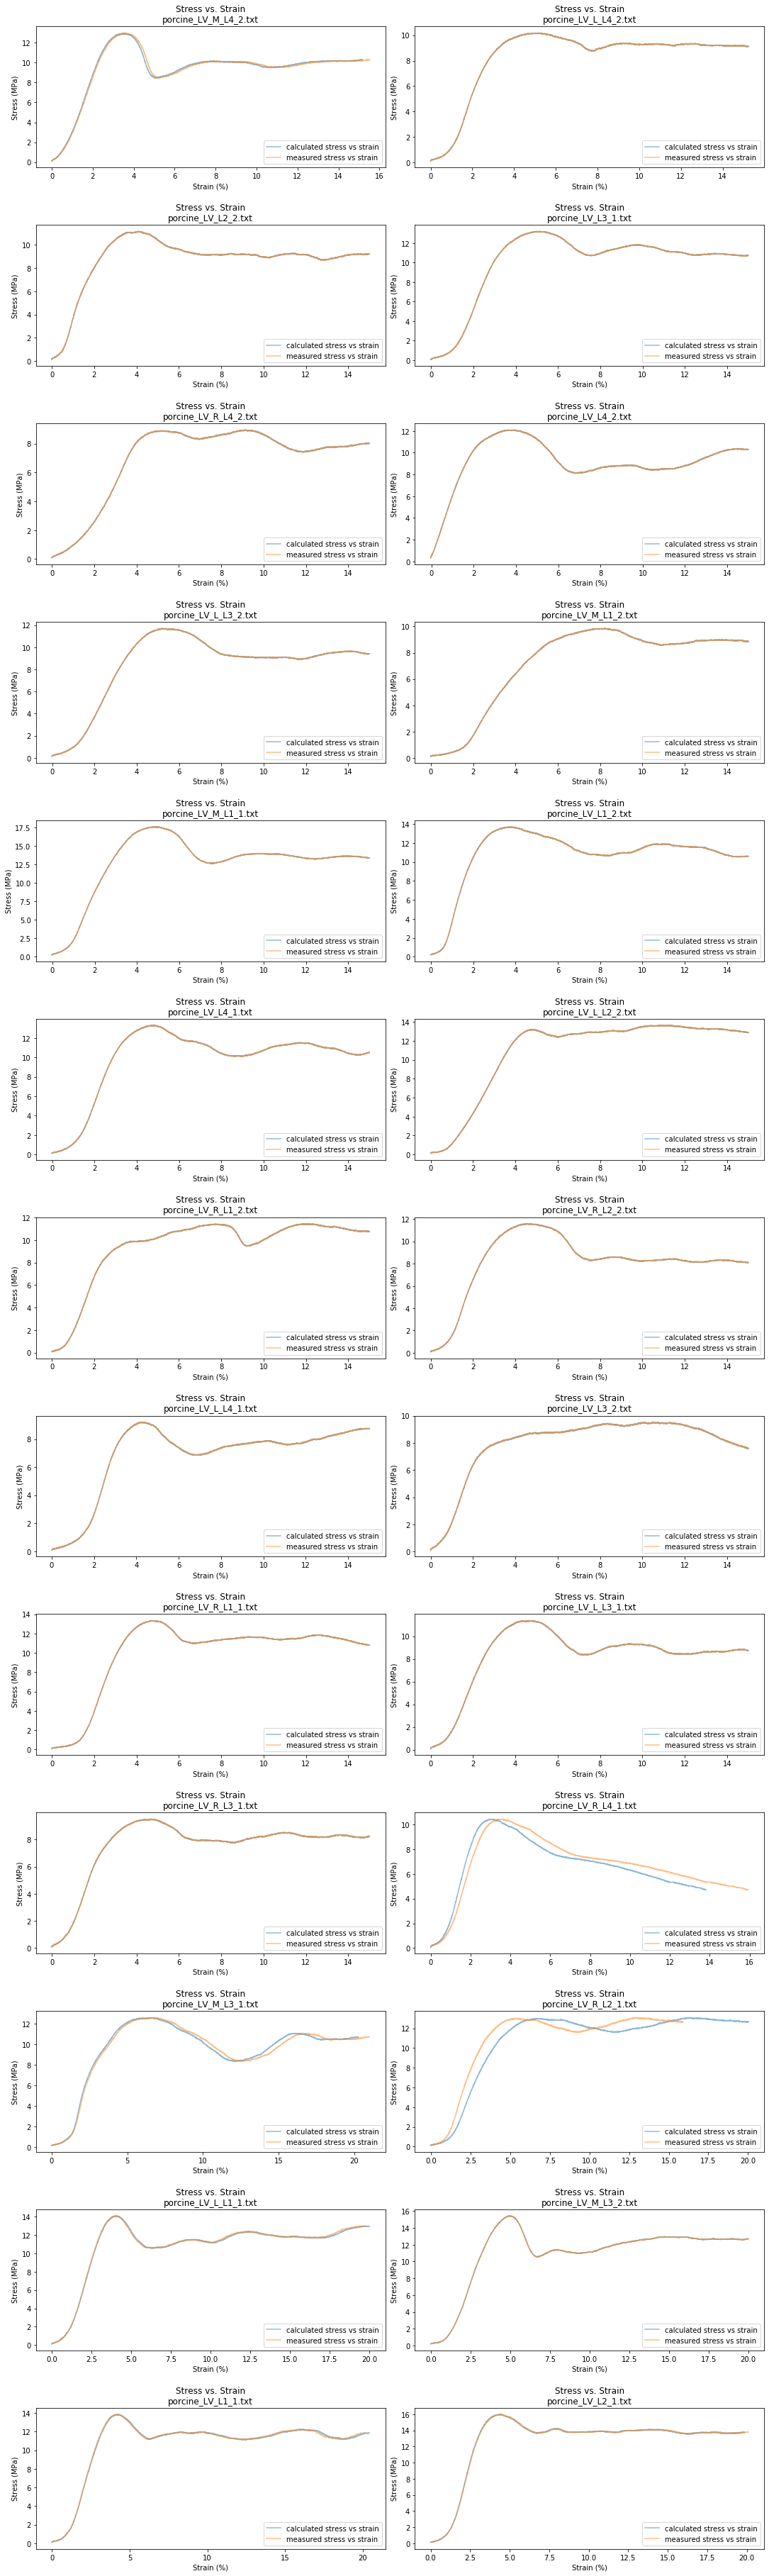

In [6]:
# initialize plot structure
fig, axs = plt.subplots(len(results) // 2, 2, figsize=(15, 50))
plt.tight_layout(h_pad=6)

# for every mechanical test plot comparison
for i, (k, v) in enumerate(results.items()):
    # plot stress vs strain
    row = i // 2
    column = i % 2
    ax = axs[row, column]
    ax.set_title(f"Stress vs. Strain\n{k}")
    ax.plot(v['Strain_calc (%)'], v['Stress_calc (MPa)'], alpha=0.5)
    ax.plot(v['Strain (%)'], v['Stress (MPa)'], alpha=0.5)
    ax.set_xlabel('Strain (%)')
    ax.set_ylabel('Stress (MPa)')
    ax.legend(["calculated stress vs strain", "measured stress vs strain"], loc='lower right')

##  Reason about differences and additional mechanical properties (in report)